In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Deep learning exp/deep ex 1.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [ ]:
dataset1.head()

,Input,Output
0,10,30
1,20,60
2,30,90
3,40,120
4,50,150


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Name:THILAK RAJ . P
# Register Number:212224040353
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.fc1(x))
    x = self.relu(self.fc2(x))
    x = self.fc3(x)
    return x






In [ ]:
# Initialize the Model, Loss Function, and Optimizer
lig = NeuralNet ()
criterion = nn. MSELoss ()
optimizer = optim.RMSprop (lig. parameters(), lr=0.001)
loss_history = []

In [ ]:
# Name:THILAK RAJ . P
# Register Number:212224040353
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range (epochs) :
      optimizer. zero_grad()
      loss = criterion(ai_brain(X_train),y_train)
      loss. backward()
      optimizer.step()
      loss_history.append(loss.item())
      if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [ ]:
train_model(lig, X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 25414.041016
Epoch [200/2000], Loss: 22112.607422
Epoch [400/2000], Loss: 14945.378906
Epoch [600/2000], Loss: 7267.349609
Epoch [800/2000], Loss: 2926.898438
Epoch [1000/2000], Loss: 1987.948120
Epoch [1200/2000], Loss: 1286.919800
Epoch [1400/2000], Loss: 662.012329
Epoch [1600/2000], Loss: 226.881470
Epoch [1800/2000], Loss: 34.510563


In [ ]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 0.096238


In [ ]:
loss_df = pd.DataFrame(loss_history, columns=["Loss"])

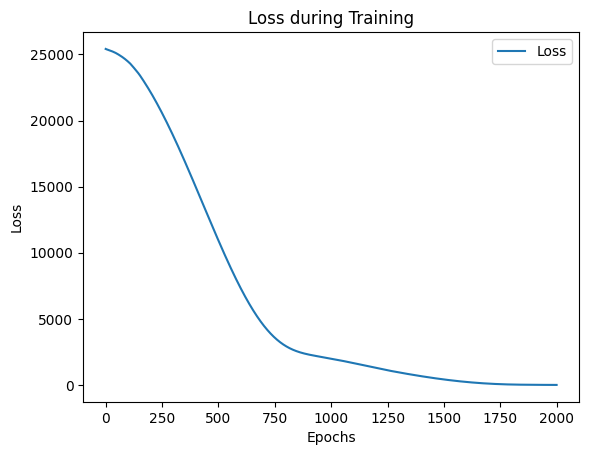

In [ ]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [ ]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 34.02835464477539
